Notebook for KPZ simulations (old)

## Main simulation

**Power jump sampling**. To sample from a jump $r$ from jump distribution $J(r, \mu)$ where $r_0 < r < \infty$, where normalized distribution is
$$
J(r, \mu) = \mu r_0^\mu r^{-(\mu+1)}
$$
we use inverse transform sampling. That is, we draw $F \sim \mathrm{Unif}[0,1]$ and then into the inverse CDF to get a draw $r$ from $J(r, \mu)$:
$$
r = r_0 (1-F)^{-1/\mu}
$$

In [1]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import matplotlib.pyplot as plt
import numpy as np
import numba
from scipy.ndimage import binary_erosion
from scipy.optimize import curve_fit
import time as _time

def sample_power_law_jump(mu: float, rng: np.random.Generator, min_jump: float = np.sqrt(2)) -> float:
    """
    Sample jump distance xi from:
        J(xi, mu) = mu * xi^(-(mu + 1)),  xi >= min_jump
    via inverse transform sampling.

    Returns jump distance r in interval [min_jump, infty]
    """
    if mu <= 0:
        raise ValueError("mu must be > 0 for a normalizable jump distribution.")
    u = rng.random()
    return min_jump * (1.0 - u) ** (-1.0 / mu)

def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(mask) < 2:
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1)
    return float(slope)


# ── Numba helpers ────────────────────────────────────────────────────────────

@numba.njit(cache=True)
def _seed_numba_rng(seed: int) -> None:
    """Seed Numba's internal RNG (separate from numpy's Generator)."""
    np.random.seed(seed)


@numba.njit(cache=True)
def _batch_step_kernel(
    grid: np.ndarray,
    occupied_xy: np.ndarray,
    n_occupied: int,
    mu: float,
    L: int,
    grid_rows: int,
    time_acc: float,
    accepted: int,
    n_steps: int,
) -> tuple:
    """Run n_steps growth attempts entirely in compiled Numba code.

    By compiling the inner step loop, all Python interpreter overhead — function
    call dispatch, attribute lookups, int/float boxing — is eliminated. Combined
    with the numpy occupied_xy array (bottleneck #3 fix), every hot-path
    operation is a plain C memory access or arithmetic instruction.

    Uses Numba's internal RNG, seeded separately via _seed_numba_rng.
    Updates grid and occupied_xy in place; returns updated scalar state.

    Args:
        grid:        (grid_rows, L) int8 grid, modified in place.
        occupied_xy: Pre-allocated (capacity, 2) int32 array of (y, x) coords.
        n_occupied:  Current number of occupied sites (active length of occupied_xy).
        mu:          Power-law jump exponent.
        L:           Grid width (columns).
        grid_rows:   Grid height (rows).
        time_acc:    Accumulated physical time so far.
        accepted:    Total occupied sites so far.
        n_steps:     Number of step attempts to run.

    Returns:
        (n_occupied, time_acc, accepted) after n_steps attempts.
    """
    two_pi = 2.0 * np.pi
    for _ in range(n_steps):
        # Sample a random source site from the flat numpy array (O(1), cache-friendly)
        idx = np.random.randint(0, n_occupied)
        sy = occupied_xy[idx, 0]
        sx = occupied_xy[idx, 1]
        pop_id = grid[sy, sx]

        # Power-law jump, min_jump = 1.0
        u = np.random.random()
        jump = (1.0 - u) ** (-1.0 / mu)
        theta = two_pi * np.random.random()
        tx = int(round(sx + jump * np.cos(theta))) % L
        ty = int(round(sy + jump * np.sin(theta)))
        time_acc += 1.0 / accepted

        if ty < 0 or ty >= grid_rows:
            continue
        if grid[ty, tx] != 0:
            continue

        grid[ty, tx] = pop_id
        occupied_xy[n_occupied, 0] = ty
        occupied_xy[n_occupied, 1] = tx
        n_occupied += 1
        accepted += 1

    return n_occupied, time_acc, accepted


@numba.njit(cache=True)
def _sd_width_kernel(
    n_col: np.ndarray,
    sum_y_col: np.ndarray,
    sum_y2_col: np.ndarray,
    ls: np.ndarray,
) -> np.ndarray:
    """Incremental sliding-window SD kernel (see simulation_scratch_wall_time_pure_SD.ipynb)."""
    L = n_col.shape[0]
    widths = np.empty(ls.shape[0])
    for li in range(ls.shape[0]):
        l = ls[li]
        n_w = 0.0; sy = 0.0; sy2 = 0.0
        for k in range(l):
            n_w  += n_col[k]
            sy   += sum_y_col[k]
            sy2  += sum_y2_col[k]
        total_sd = 0.0
        valid = 0
        for x in range(L):
            if n_w > 0.0:
                mean_y = sy / n_w
                var = sy2 / n_w - mean_y * mean_y
                if var < 0.0:
                    var = 0.0
                total_sd += var ** 0.5
                valid += 1
            x_add = (x + l) % L
            n_w  += n_col[x_add]  - n_col[x]
            sy   += sum_y_col[x_add]  - sum_y_col[x]
            sy2  += sum_y2_col[x_add] - sum_y2_col[x]
        widths[li] = total_sd / valid if valid > 0 else np.nan
    return widths


# ── Simulation class ─────────────────────────────────────────────────────────

class StochasticGrowthStripGeometry:
    """Stochastic growth on L by L SQUARE lattice with 2 populations.
    Population A_1 -> 1
    Population A_2 -> 2
    Unoccupied -> 0

    Periodic boundary conditions in x (cylinder geometry).

    Optimizations vs. original:
      - occupied_xy: pre-allocated (capacity, 2) int32 numpy array replaces
        the Python list of tuples. Eliminates heap-allocated tuple objects and
        is directly passable to Numba without conversion.
      - run() delegates to _batch_step_kernel (Numba JIT) which compiles the
        entire step loop to native code, eliminating all Python overhead per step.
    """

    def __init__(self, L: int, mu: float, seed: int = 42):
        if L < 2:
            raise ValueError("L must be at least 2")
        self.L       = int(L)
        self.mu      = float(mu)
        self.rng     = np.random.default_rng(seed)   # used by Python-side methods only
        self.grid    = np.zeros((self.L, self.L), dtype=np.int8)

        self._initialize_strip()

        capacity = self.grid.shape[0] * self.L
        self.occupied_xy = np.zeros((capacity, 2), dtype=np.int32) # holds (y, x) coordinates
        ys, xs = np.where(self.grid > 0)
        self.n_occupied = int(len(ys))
        for i, (y, x) in enumerate(zip(ys, xs)):
            self.occupied_xy[i, 0] = int(y)
            self.occupied_xy[i, 1] = int(x)

        self.time     = 0.0
        self.attempts = 0
        self.accepted = self.L   # initial strip has L occupied sites

        self.history_accepted:       List[int]        = []
        self.history_attempts:       List[int]        = []
        self.history_record_interval: List[int]       = []
        self.history_t:              List[float]      = []
        self.history_max_height:     List[float]      = []
        self.history_mean_height:    List[float]      = []
        self.history_surface_width:  List[np.ndarray] = []
        self.ls: List[int] = []

        # Seed Numba's internal RNG so _batch_step_kernel is reproducible
        _seed_numba_rng(seed)
    
    def __getstate__(self): # this is for saving and loading states
        state = self.__dict__.copy()
        # Only serialize the occupied entries, not the full pre-allocated capacity
        # Otherwise we will be saving L by L array of 32 bit ints
        # for L~10_000 thats around 400 mb per pickle!
        state['occupied_xy'] = self.occupied_xy[:self.n_occupied]
        return state

    def __setstate__(self, state): # this is for saving and loading states
        self.__dict__.update(state)
        # Restore full capacity on load
        capacity = self.grid.shape[0] * self.L
        full = np.zeros((capacity, 2), dtype=np.int32)
        full[:self.n_occupied] = self.occupied_xy
        self.occupied_xy = full
        
    def _initialize_strip(self) -> None:
        half = self.L // 2
        self.grid[0, :half] = 1
        self.grid[0, half:] = 2

    def step(self) -> bool:
        """Single Python-side growth step using the numpy occupied_xy array.

        Kept for debugging and interactive use. Production runs should use
        run(), which calls _batch_step_kernel for the entire loop.
        Note: uses self.rng (Python Generator), not Numba's RNG.
        """
        self.attempts += 1
        idx   = int(self.rng.integers(0, self.n_occupied))
        sy    = int(self.occupied_xy[idx, 0])
        sx    = int(self.occupied_xy[idx, 1])
        pop_id = int(self.grid[sy, sx])

        jump  = sample_power_law_jump(self.mu, self.rng, min_jump=1.0)
        theta = 2.0 * np.pi * self.rng.random()
        tx    = int(round(sx + jump * np.cos(theta))) % self.L
        ty    = int(round(sy + jump * np.sin(theta)))
        self.time += 1.0 / self.accepted

        if ty < 0 or ty >= self.grid.shape[0]:
            return False
        if self.grid[ty, tx] != 0:
            return False

        self.grid[ty, tx] = pop_id
        self.occupied_xy[self.n_occupied, 0] = ty
        self.occupied_xy[self.n_occupied, 1] = tx
        self.n_occupied += 1
        self.accepted   += 1
        return True

    def fill_fraction(self) -> float:
        return float(np.count_nonzero(self.grid) / (self.L * self.L))

    def max_interface_height(self) -> float:
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0
        return float(np.max(h))

    def median_interface_height(self) -> float:
        """Do not use."""
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0
        return float(np.median(h))

    def mean_interface_height(self, surface: np.ndarray) -> float:
        ys_idx, _ = np.where(surface > 0)
        return float(np.mean(ys_idx))

    def extract_surface(self) -> np.ndarray:
        binary = (self.grid > 0)
        eroded = binary_erosion(binary, border_value=1)
        return (binary ^ eroded).astype(np.uint8)

    def extract_surface_width_sd_fast(self, surface: np.ndarray, ls) -> np.ndarray:
        """Compute w(l, t) for each l in ls via Numba incremental SD kernel."""
        L = self.L
        ys_idx, xs_idx = np.where(surface > 0)
        ys_f       = ys_idx.astype(np.float64)
        n_col      = np.bincount(xs_idx, minlength=L).astype(np.float64)
        sum_y_col  = np.bincount(xs_idx, weights=ys_f,      minlength=L)
        sum_y2_col = np.bincount(xs_idx, weights=ys_f ** 2, minlength=L)
        return _sd_width_kernel(n_col, sum_y_col, sum_y2_col, np.asarray(ls, dtype=np.int64))

    def save(self, path: str) -> None:
        """Pickle the full simulation state (grid, histories, RNG state).

        Note: Numba's internal RNG state is NOT preserved by pickle.
        After loading, call _seed_numba_rng(new_seed) if exact reproducibility
        of subsequent steps is required.
        """
        import pickle
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Simulation saved to {path}  (t={self.time:.4f}, accepted={self.accepted})")

    @classmethod
    def load(cls, path: str) -> "StochasticGrowthStripGeometry":
        import pickle
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"Simulation loaded from {path}  (t={obj.time:.4f}, accepted={obj.accepted})")
        return obj

    def save_snapshot(self, out_dir: Path, t: int, save_png: bool = False) -> None:
        max_height = self.max_interface_height()
        y_bound    = int(3 * max_height)
        out_dir.mkdir(parents=True, exist_ok=True)
        if save_png:
            try:
                import matplotlib.pyplot as plt
            except Exception:
                return
            fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
            cmap = plt.matplotlib.colors.ListedColormap(["white", "#1f77b4", "#d62728"])
            ax.imshow(self.grid[:y_bound, :], origin="lower", cmap=cmap,
                      vmin=0, vmax=2, interpolation="nearest")
            ax.set_title(f"L={self.L}, mu={self.mu}, t={t}")
            ax.set_xlabel("x"); ax.set_ylabel("y")
            fig.tight_layout()
            fig.savefig(out_dir / f"snapshot_t{t:012d}.png")
            plt.close(fig)
    
    def show_sim(self) -> None:
        """Shows current simulation"""
        fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
        cmap = plt.matplotlib.colors.ListedColormap(["white", "#1f77b4", "#d62728"])
        ax.imshow(self.grid[:, :], origin="lower", cmap=cmap,
                    vmin=0, vmax=2, interpolation="nearest")
        ax.set_title(f"L={self.L}, mu={self.mu}, t={self.attempts}")
        ax.set_xlabel("x"); ax.set_ylabel("y")
        fig.tight_layout()
        return

    def run(self, n_steps: int, record_interval_true: int = 10,
            ls: list = [],
            snapshot_steps: Optional[Iterable[int]] = None,
            snapshot_dir: Optional[str] = None,
            save_snapshots: bool = False):
        """Run the simulation for n_steps with diagnostics sampled uniformly in true time.

        Uses _batch_step_kernel (Numba JIT) to execute a variable-sized batch at a time,
        then drops back to Python to record diagnostics. The batch size grows as
        sqrt(2*t*L)*Δτ + L*Δτ²/2 so that consecutive measurements are spaced by Δτ
        in true time τ (where τ ~ sqrt(t/L) asymptotically).

        Note: snapshots fire at the nearest batch boundary, not at exact attempt counts.

        Args:
            n_steps:              Total number of computational step attempts.
            record_interval_true: Desired spacing Δτ between recordings in true time.
            ls:                   Window widths for w(l, t) measurement.
            snapshot_steps:       Attempt counts at which to save PNG snapshots.
            snapshot_dir:         Directory to write snapshots into.
            save_snapshots:       Whether to save PNG images at snapshot_steps.
        """
        if not self.ls:
            if not ls:
                raise ValueError("ls has not been specified. Pass ls= to run() or set sim.ls.")
            self.ls = ls

        snapshot_set = set(snapshot_steps or [])
        out_dir      = Path(snapshot_dir) if snapshot_dir else None
        grid_rows    = self.grid.shape[0]
        steps_done   = 0
        # Initial batch: first measurement at t = L*Δτ²/2 (derived from t = L*τ²/2 with τ=Δτ)
        record_interval = round(record_interval_true**2 * self.L / 2)

        while steps_done < n_steps:
            batch = min(record_interval, n_steps - steps_done)
            print(f"Current progress: {steps_done} of {n_steps} --- {steps_done*100/n_steps:.2f} %", end="\r")

            # Entire batch runs in compiled numba code
            self.n_occupied, self.time, self.accepted = _batch_step_kernel(
                self.grid, self.occupied_xy, self.n_occupied,
                self.mu, self.L, grid_rows,
                self.time, self.accepted, batch,
            )
            self.attempts += batch
            steps_done    += batch

            # Record diagnostics (Python-side, runs infrequently)
            self.history_accepted.append(self.accepted)
            self.history_attempts.append(self.attempts)
            self.history_t.append(self.time)
            self.history_max_height.append(self.max_interface_height())
            surface = self.extract_surface()
            self.history_surface_width.append(
                self.extract_surface_width_sd_fast(surface, self.ls)
            )
            self.history_mean_height.append(self.mean_interface_height(surface))

            # Next batch size: Δt = sqrt(2*t*L)*Δτ + L*Δτ²/2, giving uniform Δτ in true time
            record_interval = int(np.ceil(
                np.sqrt(2 * self.attempts * self.L) * record_interval_true
                + record_interval_true**2 * self.L / 2
            ))
            self.history_record_interval.append(record_interval)

            # Snapshot: saves snapshot if any attempt in this batch is in snapshot_set
            if out_dir is not None and save_snapshots:
                batch_start = self.attempts - batch
                if snapshot_set & set(range(batch_start, self.attempts)):
                    self.save_snapshot(out_dir, self.attempts, save_png=True)

        return self.get_obs()

    def get_obs(self):
        return {
            "t":                     np.asarray(self.history_t,              dtype=np.float64),
            "t_compute":             np.asarray(self.history_attempts),
            "record_interval":       np.asarray(self.history_record_interval),
            "max_height_history":    np.asarray(self.history_max_height,     dtype=np.float64),
            "mean_height_history":   np.asarray(self.history_mean_height,    dtype=np.float64),
            "surface_width_history": np.asarray(self.history_surface_width,  dtype=np.float64),
            "population_size":       np.asarray(self.history_accepted),
            "accepted": self.accepted,
        }

## Single simulations

In [54]:
# ============================================================
# Initialize new simulation
# ============================================================
sim = StochasticGrowthStripGeometry(L=10_000, mu=3.6, seed=573189)
ls = list(np.logspace(np.log10(1), np.log10(1), num=1, dtype=int))
sim.ls = ls
save_ = False
# ============================================================
# Save simulation
# ============================================================
if save_:
    sim.save("xxx.pkl") 

In [2]:
# ============================================================
# Load simulation
# ============================================================
sim = StochasticGrowthStripGeometry.load("ensemble_L500000_mu3p50_t1000B_dtau10_N10/replica_seed000042.pkl")
obs = sim.get_obs() 

Simulation loaded from ensemble_L500000_mu3p50_t1000B_dtau10_N10/replica_seed000042.pkl  (t=1680.1891, accepted=1213606252)


In [55]:
# ============================================================
# Run loaded simulation
# ============================================================
save__ = False
obs = sim.run(
    n_steps=100_000_000 * 10_000,
    record_interval_true=20,
    snapshot_steps=[i for i in range(0, 1_000_000_000 + 1, 500_000)],
    snapshot_dir="temp_snapshots_L2000_mu5",
    save_snapshots=False,
)
# ============================================================
# Save loaded simulation
# ============================================================
if save__:
    sim.save("xxx.pkl")

KeyboardInterrupt: 

### Single simulation analysis

For plotting the simulation, use `plot_sim.py`

In [ ]:
import sys
from collections.abc import Mapping, Iterable

def deep_sizeof(obj, seen=None):
    """Recursively calculates total memory of an object and its contents."""
    size = sys.getsizeof(obj)
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    if isinstance(obj, dict):
        size += sum(deep_sizeof(k, seen) + deep_sizeof(v, seen) for k, v in obj.items())
    elif isinstance(obj, (list, tuple, set, frozenset)):
        size += sum(deep_sizeof(i, seen) for i in obj)
    elif hasattr(obj, '__dict__'):
        size += deep_sizeof(obj.__dict__, seen)
    elif hasattr(obj, '__slots__'):
        size += sum(deep_sizeof(getattr(obj, slot, None), seen) for slot in obj.__slots__)

    return size

print(f"Shallow: {sys.getsizeof(sim):,} bytes")
print(f"Deep:    {deep_sizeof(sim):,} bytes")

Shallow: 48 bytes
Deep:    32,000,085,288 bytes


In [3]:
def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(mask) < 2:
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1)
    return float(slope)

Slope of mean height: 0.9404499127500491
Mean interface power: 1.0486706940531958
Max height interface power: 0.846002680883466


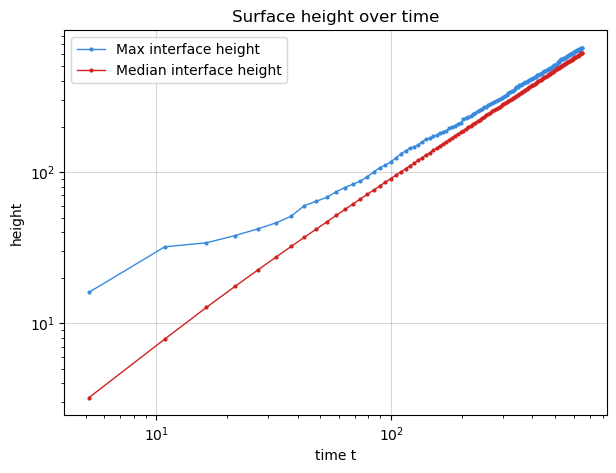

In [11]:
# ============================================================
# plot surface heights over time
# ============================================================
t = obs['t']
max_height = obs['max_height_history']
mean_height = obs['mean_height_history'] 

def model(x, m):
    return m * x + 1 # we know that at time 0, the mean height is 1

popt, pcov = curve_fit(model, t, mean_height) 
m = popt[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t, max_height, color='#378ADD', lw=1.0, marker='o', markersize=2, label="Max interface height")
ax.plot(t, mean_height, color="#d12121", lw=1.0, marker='o', markersize=2,label="Median interface height")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
ax.set_xlabel("time t")
ax.set_ylabel("height")
ax.set_title("Surface height over time")
ax.legend()
print(f"Slope of mean height: {m}")
print(f"Mean interface power: {fit_loglog_slope(t, mean_height)}")
print(f"Max height interface power: {fit_loglog_slope(t, max_height)}")

Scaling of effective time versus computational time 0.4851303287524934


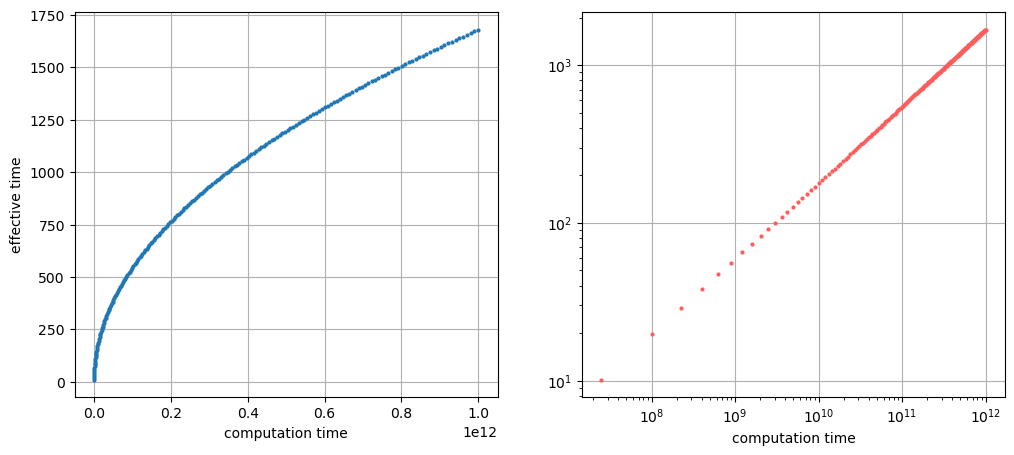

In [58]:
# ============================================================
# plot effective time versus computational time
# ============================================================
t_mean = t
att = obs["t_compute"]
print(f"Scaling of effective time versus computational time {fit_loglog_slope(att, t_mean)}")

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(att, t_mean, marker='o', markersize=2, lw=0)
ax[1].plot(att, t_mean, marker='o', markersize=2, color="#FF5C5C", lw=0)
ax[0].grid(True)
ax[1].grid(True)
ax[0].set_xlabel("computation time")
ax[1].set_xlabel("computation time")
ax[0].set_ylabel("effective time")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

slope: 713093.6418878356
scaling 1.0547582884779028


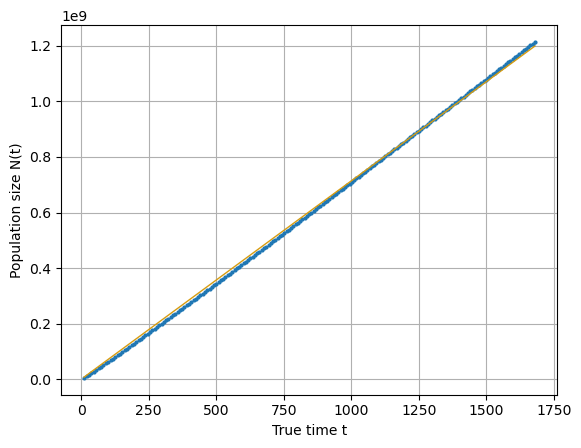

In [59]:
# ============================================================
# plot population size over time
# ============================================================
L = sim.L
def model(x, m):
    return m * x + L

N_t = obs["population_size"]

popt, pcov = curve_fit(model, t, N_t)
m = popt[0]

fig, ax = plt.subplots()
ax.plot(t, N_t, lw=0.0, marker='o', markersize=2)
ax.plot(t, m*t + L, lw=1, color="#D69C12")
ax.grid(True)
ax.set_ylabel("Population size N(t)")
ax.set_xlabel("True time t")
print(f"slope: {m}")
print(f"scaling {fit_loglog_slope(t, N_t)}")

In [45]:
# Spacing of samples in true time
delta_tau = np.asarray([t[i+1]-t[i] for i in range(len(t)-1)])
plt.plot(t[:-1], delta_tau[:], lw=0.0, marker='o', markersize=2)
fit_loglog_slope(t[:-1], delta_tau[:])

NameError: name 't' is not defined

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hd/ys7gfj7968j5gn566_yq9gvm0000gn/T/ipykernel_85859/4225597184.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"Surface width $w(l_0, t)$, L = {sim.grid.shape[1]}, $\mu$ = {sim.mu}")


Mean log-log slope: 0.6484311135286277
l = 100, alpha = 0.24681164856244905
l = 257, alpha = 0.3674385582298964
l = 663, alpha = 0.518374492443828
l = 1709, alpha = 0.6478871283385716
l = 4405, alpha = 0.7207128313890224
l = 11349, alpha = 0.7571929808036502
l = 29240, alpha = 0.7915986320720135
l = 75331, alpha = 0.7933651269809833
l = 194076, alpha = 0.8187819739957172
l = 499999, alpha = 0.8221477624701453


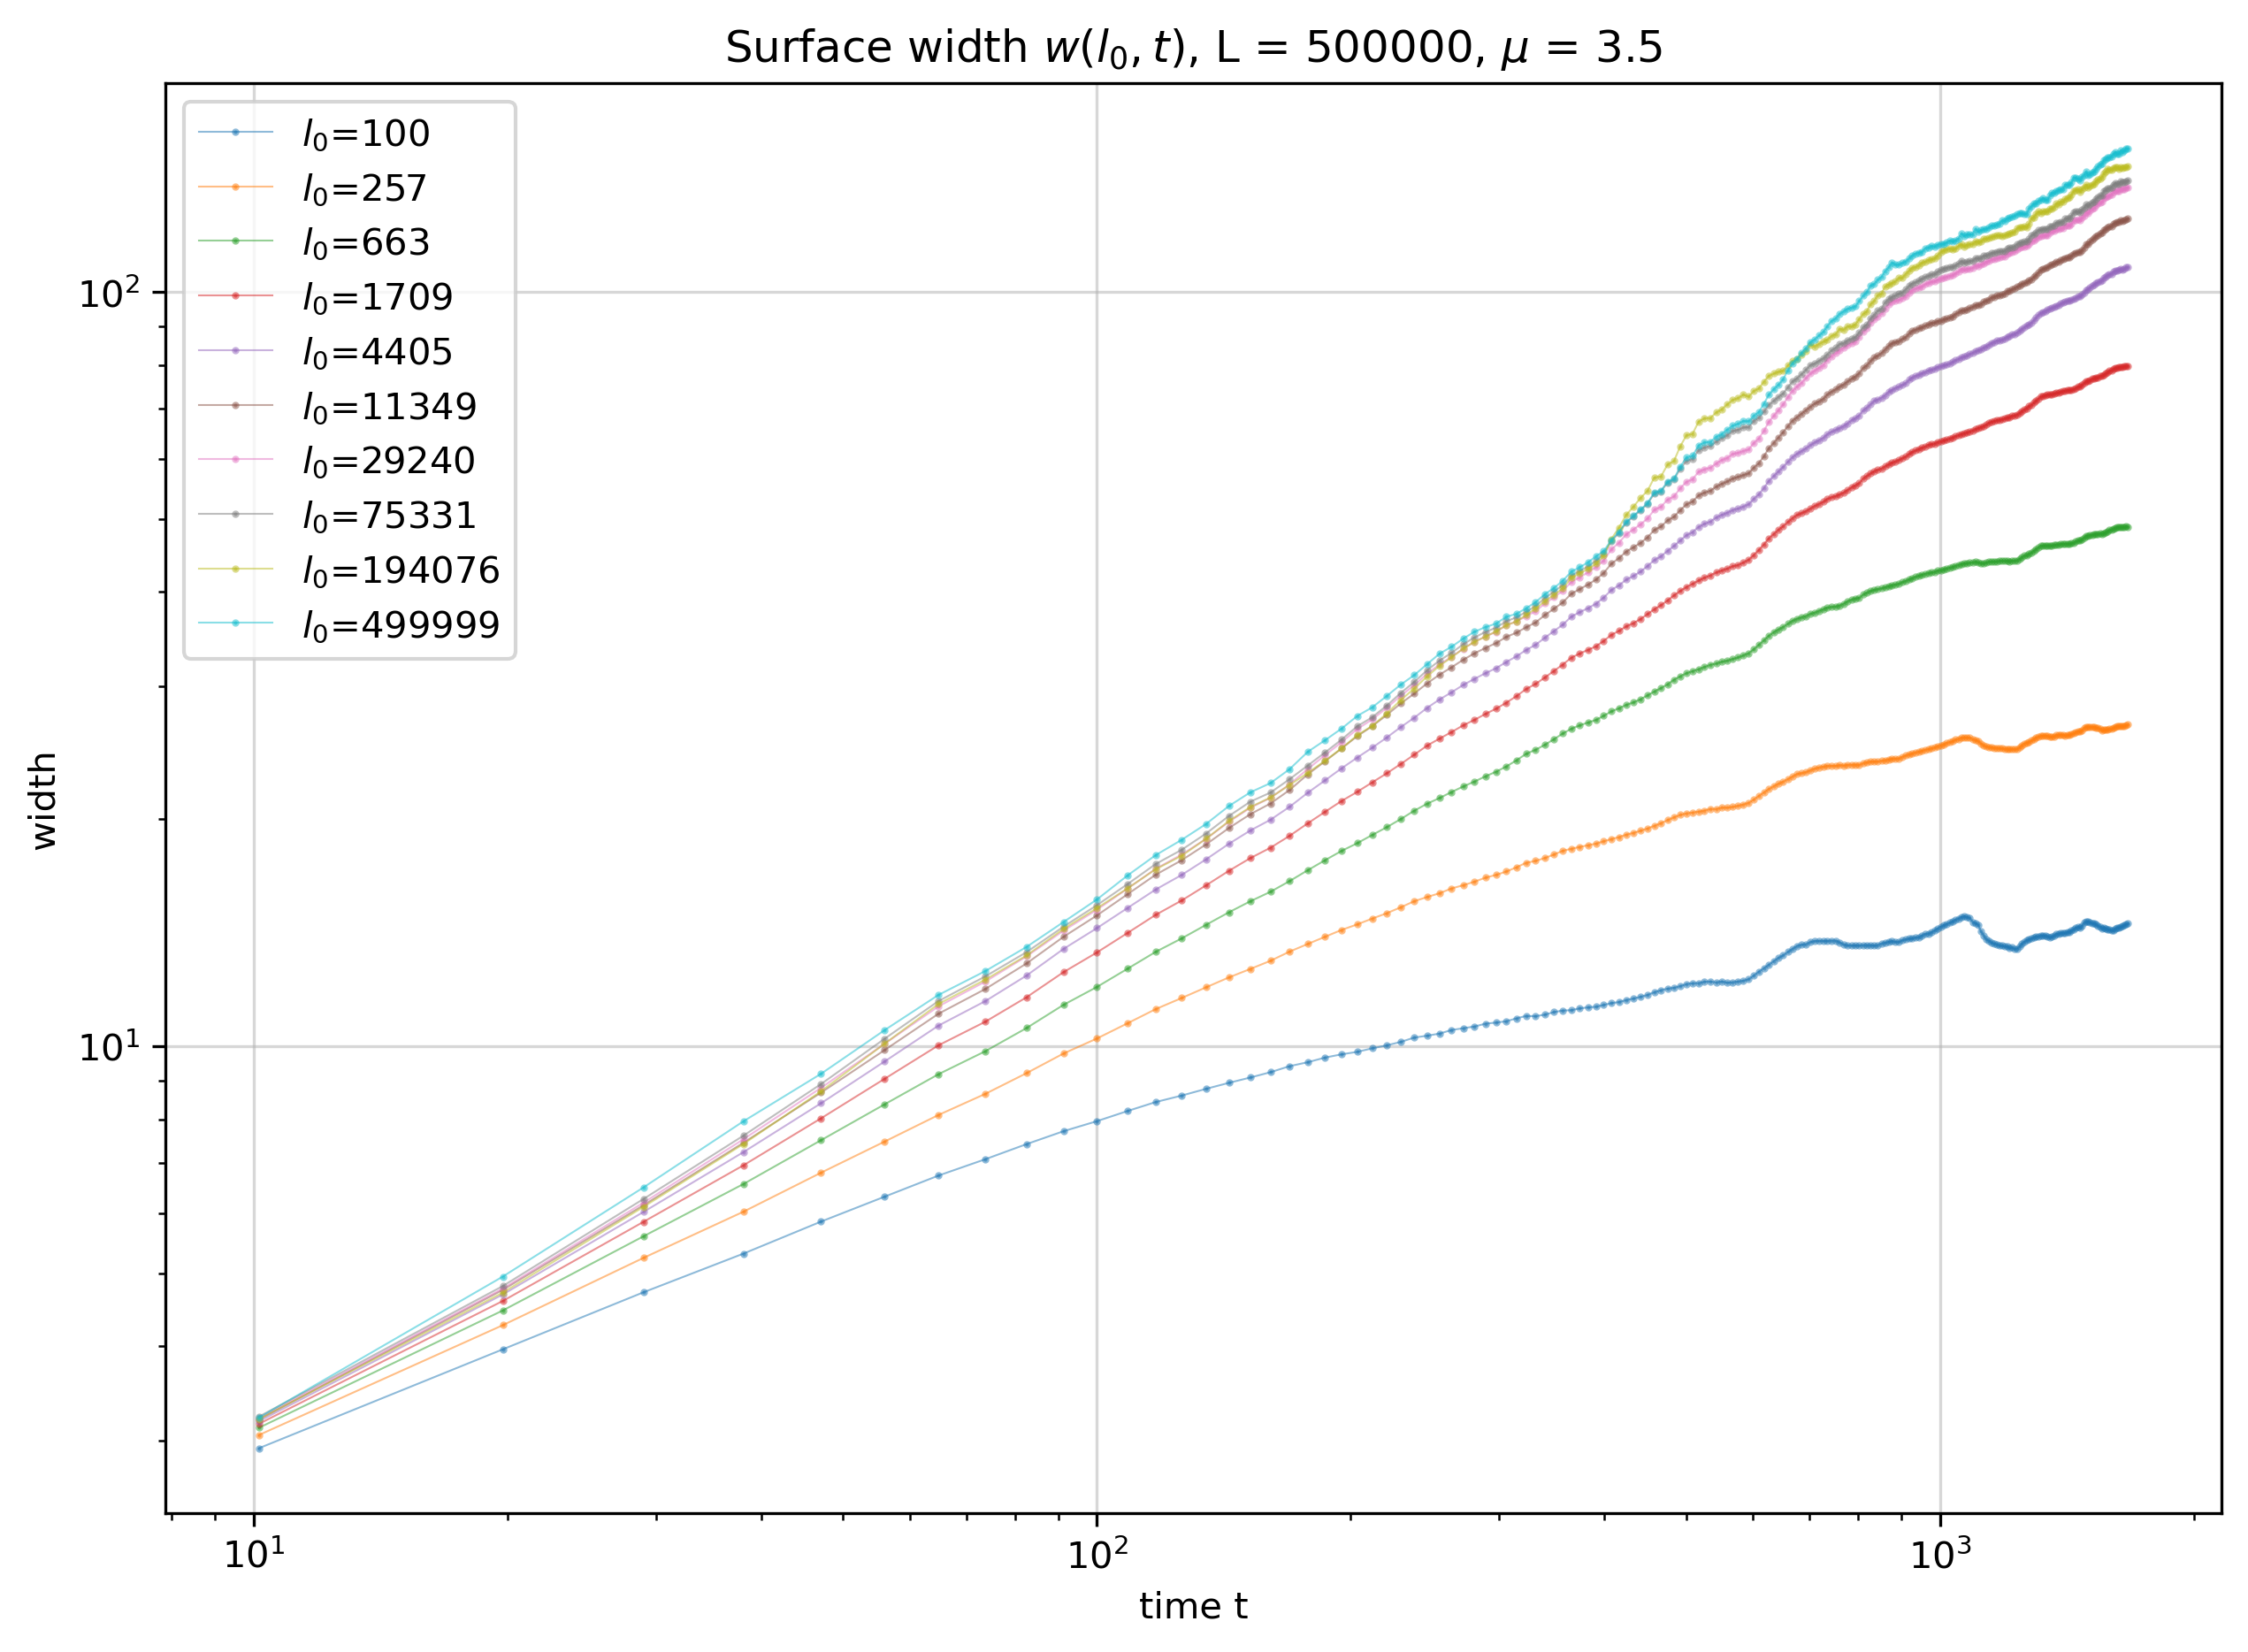

In [21]:
# ============================================================
# plot w(l_0, t) as a function of time
# ============================================================
log_log_slopes = []
t_dim, l_dim = np.shape(obs['surface_width_history'])
l_0s = sim.ls
t = obs['t']
cap = -1
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
for i, l_0 in enumerate(l_0s):
    w_l_0 = obs['surface_width_history'][:cap, i]
    log_log_slopes.append(fit_loglog_slope(t[:cap], w_l_0))
    ax.plot(t[:cap], w_l_0, lw=0.5, label=f"$l_0$={l_0}", alpha=0.5, marker='o', markersize=1)
ax.set_xlabel("time t")
ax.set_ylabel("width")
ax.set_title(f"Surface width $w(l_0, t)$, L = {sim.grid.shape[1]}, $\mu$ = {sim.mu}")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
print(f"Mean log-log slope: {np.mean(log_log_slopes)}")

for i, alpha in enumerate(log_log_slopes):
    print(f"l = {l_0s[i]}, alpha = {alpha}")

To do list:

- Extract the roughness exponent. The function $w(l, t)$ is supposed to saturate given enough time at $w^*(L)$. In this saturation regime, $w^*(L) \sim L^{\beta}$ where $\beta$ is the roughness exponent.
- Extract the dynamical exponent. For fixed $l = l_0$, the width will increase (prior to saturating) as $w(l_0, t) \sim t^{\alpha}$ where $\alpha$ is the growth exponent. Then scaling arguements say that the dynamical exponent is given as $z=\alpha/\beta$.
- Also the wandering exponent for the domain boundary

## Ensemble simulation analysis

Ensemble simulations are ran in the file `simulation_scratch_wall_time_script.py`

In [ ]:
# ============================================================
# Ensemble hyperparameters  (edit these)
# ============================================================
L                    = 50_000     # lattice side length
mu                   = 5.0       # power-law jump exponent
ls                   = list(np.unique(np.logspace(np.log10(100), np.log10(L), num=10, dtype=int)))
n_steps              = 1_000_000 * 10_000  # computational steps per replica
record_interval_true = 5     # desired spacing Δτ between recordings in true time
N_ensemble           = 20        # number of independent replicas
base_seed            = 42        # seeds will be base_seed, base_seed+1, ...

# ── Derived names ─────────────────────────────────────────────────────────────
_mu_tag   = f"{mu:.2f}".replace(".", "p")
_t_tag    = f"{n_steps // 1_000_000}M"
batch_tag = f"ensemble_L{L}_mu{_mu_tag}_t{_t_tag}_dtau{record_interval_true}_N{N_ensemble}"
batch_dir = Path(batch_tag)
batch_dir.mkdir(exist_ok=True)

def _replica_path(seed: int) -> Path:
    return batch_dir / f"replica_seed{seed:06d}.pkl"

seeds = [base_seed + i for i in range(N_ensemble)]

print(f"Ensemble: N={N_ensemble}  L={L}  mu={mu}  n_steps={n_steps:,}  record_interval_true={record_interval_true}  ls={ls}")
print(f"Checkpoints: {batch_dir}/")

# ============================================================
# Read in ensemble and get observables
# ============================================================
obs_list: list[dict] = []

for rank, seed in enumerate(seeds):
    ckpt = _replica_path(seed)
    t0   = _time.perf_counter()

    # Checks if a replica already exists if it does,
    # load that replica. If not, instantiates new replica.
    if ckpt.exists():
        sim_r = StochasticGrowthStripGeometry.load(str(ckpt))
        print(f"[{rank+1}/{N_ensemble}] Loaded seed={seed}  (attempts={sim_r.attempts:,})")
        remaining = max(0, n_steps - sim_r.attempts)
    else:
        print(f"Error: seed={seed} at path {str(ckpt)} does not exist")
        continue

    obs = sim_r.get_obs()
    obs_list.append(obs)
    print(f"    done in {_time.perf_counter()-t0:.1f}s  |  records={len(obs['t'])}") # timing

print(f"\n Complete.")

Ensemble: N=20  L=50000  mu=5.0  n_steps=10,000,000,000  record_interval_true=5  ls=[np.int64(100), np.int64(199), np.int64(397), np.int64(793), np.int64(1583), np.int64(3158), np.int64(6299), np.int64(12566), np.int64(25065), np.int64(49999)]
Checkpoints: ensemble_L50000_mu5p00_t10000M_dtau5_N20/
Simulation loaded from ensemble_L50000_mu5p00_t10000M_dtau5_N20/replica_seed000042.pkl  (t=651.2860, accepted=30899529)
[1/20] Loaded seed=42  (attempts=10,000,000,000)
    done in 1.0s  |  records=127
Simulation loaded from ensemble_L50000_mu5p00_t10000M_dtau5_N20/replica_seed000043.pkl  (t=651.3836, accepted=30911315)
[2/20] Loaded seed=43  (attempts=10,000,000,000)
    done in 0.9s  |  records=127
Simulation loaded from ensemble_L50000_mu5p00_t10000M_dtau5_N20/replica_seed000044.pkl  (t=651.6701, accepted=30901925)
[3/20] Loaded seed=44  (attempts=10,000,000,000)
    done in 0.8s  |  records=127
Simulation loaded from ensemble_L50000_mu5p00_t10000M_dtau5_N20/replica_seed000045.pkl  (t=651.

Stacked shape: (20, 127, 10)  →  mean shape: (127, 10)


<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/var/folders/hd/ys7gfj7968j5gn566_yq9gvm0000gn/T/ipykernel_46791/3583621221.py:49: SyntaxWarning: invalid escape sequence '\p'
  + f"\n(shaded: $\pm$ SEM)"


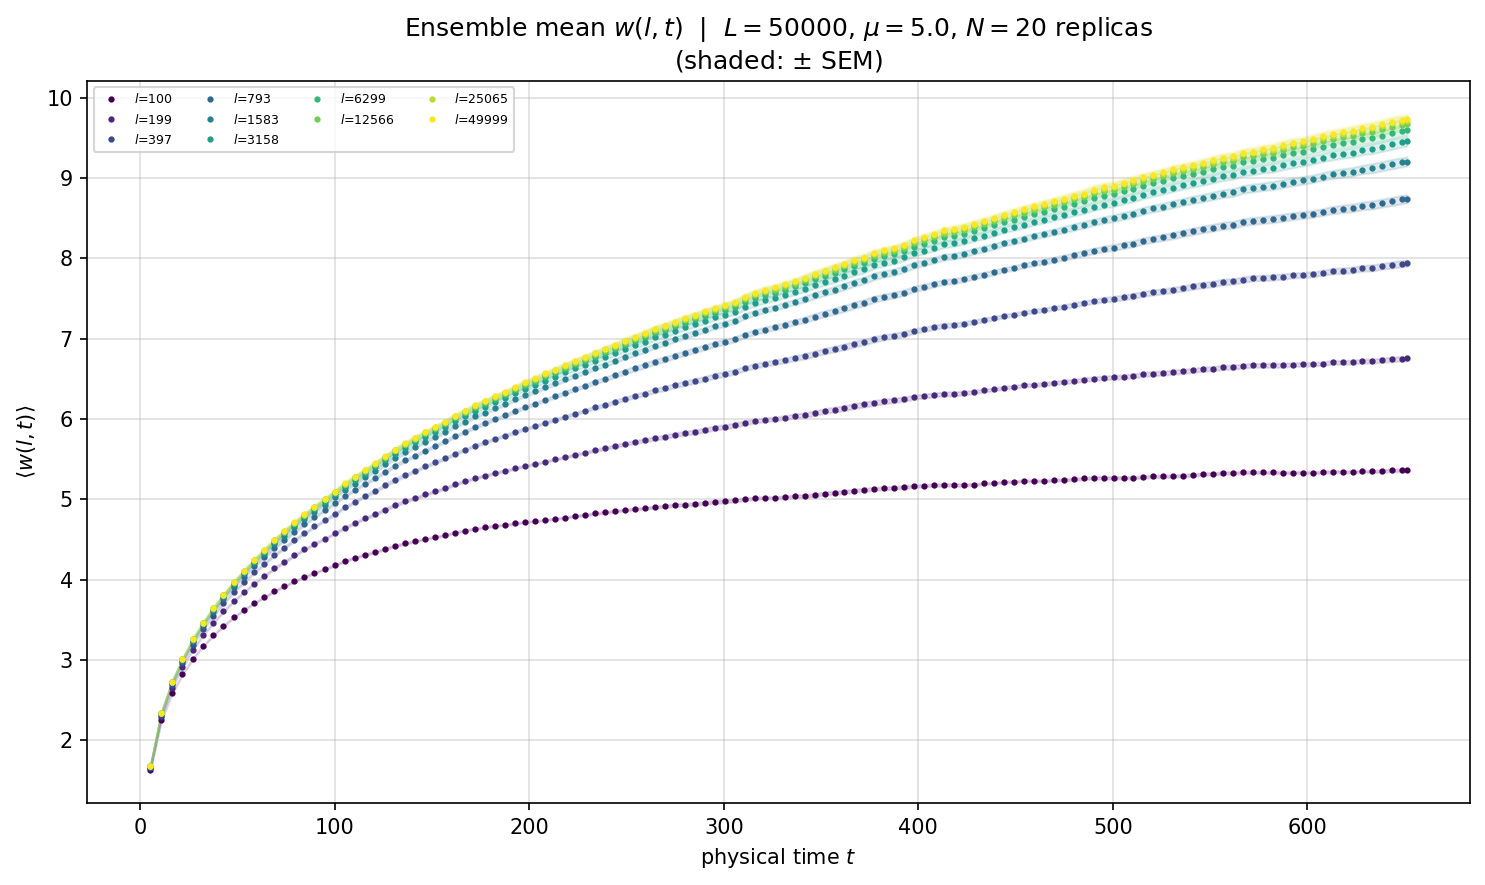


Mean growth exponent alpha across all l: 0.311
  l=  100  alpha=0.189
  l=  199  alpha=0.250
  l=  397  alpha=0.293
  l=  793  alpha=0.319
  l= 1583  alpha=0.334
  l= 3158  alpha=0.341
  l= 6299  alpha=0.345
  l=12566  alpha=0.347
  l=25065  alpha=0.348
  l=49999  alpha=0.348


In [ ]:
# ============================================================
# Ensemble-average w(l, t)
# ============================================================
# surface_width_history shape per replica: (T_records, len_ls)
# T_records may differ slightly between replicas if they were resumed at
# different points; trim to the shortest common time before stacking.
# This code will rarely do anything unless the loop above is interrupted.
min_T     = min(o['surface_width_history'].shape[0] for o in obs_list)
sw_stack  = np.stack(
    [o['surface_width_history'][:min_T] for o in obs_list], axis=0
)  # (N_ensemble, min_T, len_ls)

sw_mean  = np.mean(sw_stack, axis=0)   # (min_T, len_ls)
sw_std   = np.std(sw_stack,  axis=0)   # (min_T, len_ls)
sw_sem   = sw_std / np.sqrt(N_ensemble) # contains time_std and w_std. 
# TODO: I'm forgetting some basic statistics here. come back and figure out how this 
# is working. (e.g. why divide by sqrt(N_ensemble))

# Physical time axis: average over replicas (they differ only by O(1/N) noise)
t_mean = np.mean(
    np.stack([o['t'][:min_T] for o in obs_list], axis=0), axis=0
)

print(f"Stacked shape: {sw_stack.shape}  →  mean shape: {sw_mean.shape}")

# ============================================================
# Quick diagnostic plot: ensemble-mean w(l_0, t) for every l
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(ls)))

for i, l_val in enumerate(ls):
    if (i+1) % 1 == 0:
        ax.plot(t_mean, sw_mean[:, i], color=cmap_lines[i], lw=0, marker='o',
                markersize=2, label=f"$l$={l_val}")
        ax.fill_between(
            t_mean,
            sw_mean[:, i] - sw_sem[:, i],
            sw_mean[:, i] + sw_sem[:, i],
            color=cmap_lines[i], alpha=0.15,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("physical time $t$")
ax.set_ylabel(r"$\langle w(l,t) \rangle$")
ax.set_title(
    rf"Ensemble mean $w(l,t)$  |  $L={L}$, $\mu={mu}$, $N={N_ensemble}$ replicas"
    + f"\n(shaded: $\pm$ SEM)"
)
ax.legend(fontsize=6, ncol=4, loc="upper left")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Growth-exponent estimate from ensemble mean (slope of log w vs log t)
alpha_estimates = [fit_loglog_slope(t_mean, sw_mean[:, i]) for i in range(len(ls))]
print(f"\nMean growth exponent alpha across all l: {np.mean(alpha_estimates):.3f}")
for l_val, alpha in zip(ls, alpha_estimates):
    print(f"  l={l_val:5d}  alpha={alpha:.3f}")

Todo:
- Once done with the single simulation analysis, get claude to generalize this to multiple ensembles.

In [15]:
import sys 

def deep_sizeof(obj, seen=None):
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)
    size = sys.getsizeof(obj)
    if isinstance(obj, dict):
        size += sum(deep_sizeof(k, seen) + deep_sizeof(v, seen) for k, v in obj.items())
    elif hasattr(obj, '__iter__') and not isinstance(obj, (str, bytes)):
        size += sum(deep_sizeof(i, seen) for i in obj)
    return size

In [42]:
a = sim.grid
print(f"{sys.getsizeof(a) / 1024 ** 2:.4f} MB")

0.0001 MB


In [43]:
a_nparr = np.array(a)
a_nparr.size

4000000000

In [35]:
np.array(a).dtype

dtype('float64')

In [44]:
print(f"{np.array(a).nbytes / 1024**2:.6f} MB")

3814.697266 MB
